In [4]:
import requests
import pandas as pd
pd.set_option('display.max_columns', 500)

# 1. Fetch the JSON data
url = "https://yields.llama.fi/pools"
response = requests.get(url)
data = response.json()

if data.get("status") == "success":
    pools_data = data["data"]
    print(f"Successfully fetched data for {len(pools_data)} pools.")
    
    # 3. Convert to a pandas DataFrame for easy analysis
    df = pd.DataFrame(pools_data)
    df["underlyingTokens"] = df["underlyingTokens"].astype(str)

Successfully fetched data for 19258 pools.


In [5]:
pools_data[0]
df['symbol'].value_counts()
df[df["symbol"].str.lower().str.contains("reusd")][[
    "chain",
    "project",
    "symbol",
    "apy",
    "pool",
    "poolMeta",
]].sort_values("project")
# df[df["project"].str.lower().str.contains("midas")]

# df[df["underlyingTokens"].str.contains("0x7CF9DEC92ca9FD46f8d86e7798B72624Bc116C05")]
# df["underlyingTokens"].astype(str)

,chain,project,symbol,apy,pool,poolMeta
14763,Ethereum,beefy,REUSD-SFRXUSD,9.01644,f4074e82-16d1-4860-9153-7921de5a4337,Convex
4523,Ethereum,beefy,REUSD,9.92213,7adf2ebf-cbc3-492a-a9c4-3db96e6bf03c,Magpie-25Jun26
3629,Ethereum,beefy,REUSDE,20.19976,67726209-e2d9-45e6-b8c1-8e43c4a7f360,Magpie-25Jun26
15289,Ethereum,beefy,REUSD-SDOLA,8.62852,0a4f1d22-a3e7-4c9d-81c4-2484f2860eb3,Convex
2635,Ethereum,beefy,REUSD-SCRVUSD,8.56487,8fa62205-3835-4407-8b40-936b4125f2ad,Convex
4250,Avalanche,blackhole-amm,REUSD-USDC,0.03173,da883726-69db-4aa8-a329-2c2627d49338,None
3199,Avalanche,blackhole-clmm,REUSD-USDC,1.55592,8f169a34-dabc-46a3-b0fe-58e75a337611,CL - 1
5643,Ethereum,convex-finance,REUSD-FXUSD,17.27270,bd685d54-44b7-4b98-a2a8-4ecc22b59d66,None
1059,Ethereum,convex-finance,REUSD-SCRVUSD,8.65299,1971c939-46e4-4b86-87d9-78308de47af7,None
2397,Ethereum,convex-finance,REUSD-SFRXUSD,9.30419,0a84dcf2-f71a-4863-bd2e-1952a043eb0c,None


In [33]:
url = "https://yields.llama.fi/chart/0aedb3f6-9298-49de-8bb0-2f611a4df784"
# url = "https://yields.llama.fi/chart/2ad8497d-c855-4840-85ad-cdc536b92ced"
response = requests.get(url)
yield_hist = response.json()

if data.get("status") == "success":
    yield_hist = pd.DataFrame(yield_hist["data"])
    yield_hist['timestamp'] = pd.to_datetime(yield_hist['timestamp'])
    yield_hist = yield_hist.sort_values('timestamp')
yield_hist.head()


,timestamp,tvlUsd,apy,apyBase,apyReward,il7d,apyBase7d
0,2024-09-23 23:01:30.641000+00:00,8988718,4.47118,4.47118,None,None,None
1,2024-09-24 23:01:40.244000+00:00,8978256,5.27843,5.27843,None,None,None
2,2024-09-25 23:01:43.078000+00:00,8966006,5.27843,5.27843,None,None,None
3,2024-09-26 23:01:26.157000+00:00,9019931,8.92262,8.92262,None,None,None
4,2024-09-27 23:01:36.520000+00:00,9026944,5.65460,5.65460,None,None,None


In [32]:
yield_hist1 = yield_hist

<Axes: >

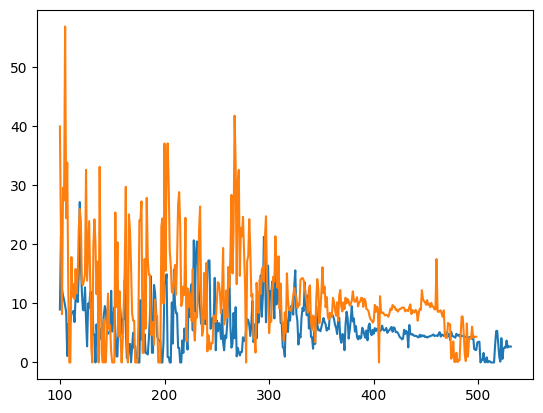

In [41]:
yield_hist[100:]["apy"].plot()
yield_hist1[100:]["apy"].plot()

In [39]:
yield_hist["timestamp"].astype(str).str[:10]

0      2024-09-23
1      2024-09-24
2      2024-09-25
3      2024-09-26
4      2024-09-27
          ...    
527    2026-03-04
528    2026-03-05
529    2026-03-06
530    2026-03-07
531    2026-03-08
Name: timestamp, Length: 532, dtype: object

In [37]:
df.head(3)

,chain,project,symbol,tvlUsd,apyBase,apyReward,apy,rewardTokens,pool,apyPct1D,apyPct7D,apyPct30D,stablecoin,ilRisk,exposure,predictions,poolMeta,mu,sigma,count,outlier,underlyingTokens,il7d,apyBase7d,apyMean30d,volumeUsd1d,volumeUsd7d,apyBaseInception
0,Ethereum,lido,STETH,18088576216,2.33200,NaN,2.33200,None,747c1d2a-c668-4682-b9f9-296708a3dd90,-0.00800,-0.03100,-0.24300,False,no,single,"{'predictedClass': 'Stable/Up', 'predictedProb...",None,3.57475,0.05318,1374,False,['0x0000000000000000000000000000000000000000'],None,NaN,2.41536,NaN,NaN,NaN
1,Ethereum,binance-staked-eth,WBETH,6791645488,2.53492,NaN,2.53492,None,80b8bf92-b953-4c20-98ea-c9653ef2bb98,-0.02738,-0.10074,-1.04172,False,no,single,"{'predictedClass': 'Stable/Up', 'predictedProb...",None,3.02384,0.03078,995,False,['0x0000000000000000000000000000000000000000'],None,NaN,2.60875,NaN,NaN,NaN
2,Ethereum,sky-lending,SUSDS,5993377985,NaN,NaN,4.00000,None,d8c4eff5-c8a9-46fc-a888-057c4c668e72,0.00000,0.00000,0.00000,True,no,single,"{'predictedClass': 'Stable/Up', 'predictedProb...",None,4.61250,0.03489,381,False,['0xdC035D45d973E3EC169d2276DDab16f1e407384F'],None,NaN,4.00000,NaN,NaN,NaN


In [1]:
import requests
import pandas as pd
pd.set_option('display.max_columns', 500)

url = "https://yields.llama.fi/pools"
response = requests.get(url)
data = response.json()

if data.get("status") == "success":
    pools_data = data["data"]
    print(f"Successfully fetched data for {len(pools_data)} pools.")
    
    df = pd.DataFrame(pools_data)
    df["underlyingTokens"] = df["underlyingTokens"].astype(str)


/Users/yegortrussov/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Successfully fetched data for 19199 pools.


In [ ]:


def fetch_token_yields(pools):
    result = []
    for pool in pools:
        url = f"https://yields.llama.fi/chart/{pool}"

        response = requests.get(url)
        yield_hist = response.json()

        if data.get("status") == "success":
            yield_hist = pd.DataFrame(yield_hist["data"])
            yield_hist['timestamp'] = pd.to_datetime(yield_hist['timestamp'])
            yield_hist = yield_hist.sort_values('timestamp')
            yield_hist["date"] = yield_hist["timestamp"].astype(str).str[:10]
            yield_hist = yield_hist.drop(columns=["apyReward", "il7d", "apyBase7d", "tvlUsd", "timestamp"])
            meta = df[df["pool"] == pool]
            yield_hist["symbol"] = meta["symbol"].unique()[0].lower()
            yield_hist["project"] = meta["project"].unique()[0].lower()

            result.append(yield_hist)
    result = pd.concat(result)
    result.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/tokens_yield_hist.csv", index=False)


fetch_token_yields([
    "0aedb3f6-9298-49de-8bb0-2f611a4df784", # RLP
    "2ad8497d-c855-4840-85ad-cdc536b92ced", # RLP
    "402b0554-9525-40af-8703-3c59b0aa863c", # SRUSD 
    "d8c4eff5-c8a9-46fc-a888-057c4c668e72", # SUSDS
])


/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_27835/4251100959.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(result)
